# Import + Define useful functions

In [317]:
import matplotlib.pyplot as plt
from astropy import units as u
from tardis import run_tardis
import networkx as nx
from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d as gauss
import pandas as pd
import math

In [318]:
def residuals(y1, y2):
    """Calculate the residuals between two lists of luminosities."""
    residual = []
    for i, j in zip(y1, y2):
        residual.append((i - j))
    return residual

In [319]:
def moving_avg_wl(x_data, y_data, window_width):
    """Calculates the moving average of the y_data based on the x_data and a specified window width in angstroms."""
    if window_width <= 0:
        raise ValueError("Window width must be positive.")

    y_avgs = []
    x_mov = []

    half_width = window_width / 2

    for r in range(len(x_data)):
        x_center = x_data[r]

        y_sum = 0
        count = 0

        for i in range(len(x_data)):
            if abs(x_data[i] - x_center) <= half_width:
                y_sum += y_data[i]
                count += 1

        if count > 0:
            y_avgs.append(y_sum / count)
            x_mov.append(x_center)

    return x_mov, y_avgs


def moving_avg_ind(x_data, y_data, window_size):
    """Calculates the moving average of the y_data based on the x_data and a specified window width in indices."""
    if window_size < 1:
        raise ValueError("Window size must be at least 1.")
    y_avgs = []
    
    for r in range(len(y_data)):
        y_sum = 0
        for i in range(window_size):
            try:
                y_sum += y_data[(r + i) - (window_size // 2)]
            except IndexError:
                pass
        y_avg = y_sum / window_size
        y_avgs.append(y_avg)

    x_mov = x_data[:len(y_avgs)]#    return x_mov, y_avgs
    return x_mov, y_avgs

In [320]:
def fracdif(l1, l2):
    """Calculate the fractional difference between two lists of luminosities."""
    fracdiff = []
    
    for a, b in zip(l1, l2):
        if a != 0:
            fracdiff.append(100*(abs(a-b)/a))
        else:
            fracdiff.append(0)
    return fracdiff

In [321]:
def signal_to_noise(y, start, stop):
    """Calculates the signal to noise ratio of a list of luminosities between specified start and stop indices."""
    # Calculation assumes y values are in ergs/sec
    # Returns SNR

    y_range = y[start:stop]

    mean = sum(y_range) / len(y_range)

    stddev = (sum((x - mean) ** 2 for x in y_range) / (len(y_range)-1)) ** 0.5
    print("Standard Deviation = {}".format(stddev))

    snr = (mean / stddev)
    return snr

In [322]:
def moving_std_wavelength(x, y, window_width):
    """Compute moving standard deviation using a wavelength-based window."""
    
    x = np.asarray(x)
    y = np.asarray(y)
    
    half_window = window_width / 2
    stds = np.zeros_like(y)

    left = 0
    right = 0

    for i in range(len(x)):
        # Expand right bound
        while right < len(x) and x[right] <= x[i] + half_window:
            right += 1
        
        # Shrink left bound
        while x[left] < x[i] - half_window:
            left += 1
        
        window_vals = y[left:right]
        
        if len(window_vals) > 1:
            stds[i] = np.std(window_vals)
        else:
            stds[i] = np.nan  # or 0, depending on preference

    return stds

# Read the data from the Kerzendorf 2014 Simulations

### This section reads the data from tardis_example_spec.dat and tardis_example_spec_virt.dat and plots it
### These files can be found in the TARDIS Setups folder under 2014/2014_kerzendorf_sim

Read the data from the real spectrum .dat file and store the wavelengths and luminosities in separate lists. Reverse them for ease of use later on.

In [323]:
specdat = open("tardis_example_spec.dat", "r")
specdat.readline() # skip header

x_real = []
y_real = []

for line in specdat:
    if line:
        parts = line.split()
        x_real.append(float(parts[0]))
        y_real.append(float(parts[1]))


x_real.reverse()
y_real.reverse()

Read the data from the virtual spectrum .dat file and store the wavelengths and luminosities in separate lists. Reverse them for ease of use later on.

In [324]:
specdatvirt = open("tardis_example_spec_virt.dat", "r")
specdatvirt.readline() # skip header

x_virt = []
y_virt = []

for line in specdatvirt:
    if line:
        parts = line.split()
        x_virt.append(float(parts[0]))
        y_virt.append(float(parts[1]))

x_virt.reverse()
y_virt.reverse()

Plot the real and virtual spectra on the same graph to make sure data was read correctly.

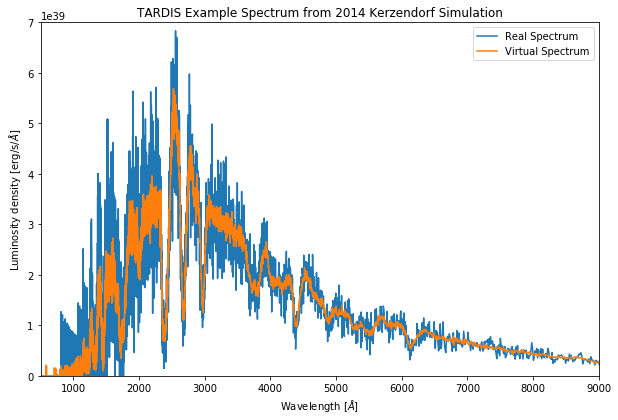

In [325]:
plt.figure(figsize=(10, 6.5))
plt.plot(x_real, y_real, label="Real Spectrum")
plt.plot(x_virt, y_virt, label="Virtual Spectrum")

plt.xlim(500, 9000)
plt.ylim(0, 7e39)
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Luminosity density [erg/s/$\AA$]")
plt.title("TARDIS Example Spectrum from 2014 Kerzendorf Simulation")
plt.legend()
plt.show()

# Define interested ranges

### These ranges can be altered to calculate the SNR in different regions of the spectrum. The ranges should be chosen to avoid strong spectral features, as these can skew the SNR calculation.

Range 1

In [326]:
start1 = 2175
stop1 = 2275

start1_index = np.searchsorted(x_real, start1)
stop1_index = np.searchsorted(x_real, stop1)


Range 2

In [327]:
start2 = 3100
stop2 = 3200

start2_index = np.searchsorted(x_real, start2)
stop2_index = np.searchsorted(x_real, stop2)

Range 3

In [328]:
start3 = 6800
stop3 = 7000

start3_index = np.searchsorted(x_real, start3)
stop3_index = np.searchsorted(x_real, stop3)

# Measuring Montecarlo Noise

### In this section, we measure the Signal to Noise Ratio and the Standard Deviation of the files in the TARDIS Setups folder in all three defined ranges

### Range 1

In [329]:
snr = signal_to_noise(y_real, start1_index, stop1_index)

#print(spec_wavs[start1:stop1])
print("SNR for {} to {} Angstroms = {}".format(start1, stop1, snr))

snrv = signal_to_noise(y_virt, start1_index, stop1_index)
#print(spec_wavs[start1:stop1])
print("SNR for {} to {} Angstroms = {}".format(start1, stop1, snrv))

Standard Deviation = 8.62443485968e+38
SNR for 2175 to 2275 Angstroms = 3.94671158585
Standard Deviation = 2.07561979705e+38
SNR for 2175 to 2275 Angstroms = 16.2397071865


### Range 2

In [330]:
snr = signal_to_noise(y_real, start2_index, stop2_index)
#print(spec_wavs[start2:stop2])
print("SNR for {} to {} Angstroms = {}".format(start2, stop2, snr))

snrv = signal_to_noise(y_virt, start2_index, stop2_index)
#print(spec_wavs[start2:stop2])
print("SNR for {} to {} Angstroms = {}".format(start2, stop2, snrv))

Standard Deviation = 5.15455827261e+38
SNR for 3100 to 3200 Angstroms = 5.96730967792
Standard Deviation = 1.11923385779e+38
SNR for 3100 to 3200 Angstroms = 28.5224266866


### Range 3

In [331]:
snr = signal_to_noise(y_real, start3_index, stop3_index)
#print(spec_wavs[start3:stop3])
print("SNR for {} to {} Angstroms = {}".format(start3, stop3, snr))

snrv = signal_to_noise(y_virt, start3_index, stop3_index)
#print(spec_wavs[start3:stop3])
print("SNR for {} to {} Angstroms = {}".format(start3, stop3, snrv))

Standard Deviation = 9.86670370226e+37
SNR for 6800 to 7000 Angstroms = 6.94490658259
Standard Deviation = 3.1197627424e+37
SNR for 6800 to 7000 Angstroms = 22.1105253359


# Smooth the Kerz_2014 data using a Moving Windowed Average

### In this section, we use a Moving Windowed Average to reduce the noise in the data from the TARDIS Setups folder

Define the window size in angstroms and call the function to get the moving averages for both the real and virtual spectra.

In [332]:
wl_wsize = 65

x_mov, y_mov = moving_avg_wl(x_real, y_real, wl_wsize)
xv_mov, yv_mov = moving_avg_wl(x_virt, y_virt, wl_wsize)


Define the window size in indices and call the function to get the moving averages for both the real and virtual spectra.

In [333]:
ind_wsize = 65

x_mov_i, y_mov_i = moving_avg_ind(x_real, y_real, ind_wsize)
xv_mov_i, yv_mov_i = moving_avg_ind(x_virt, y_virt, ind_wsize)

print("Window Sizes in Angstroms:")
print("Start of Spectrum: {} to {} ({} Angstroms)".format(x_real[0], x_real[ind_wsize-1], x_real[ind_wsize-1] - x_real[0]))
print("End of Spectrum: {} to {} ({} Angstroms)".format(x_real[len(x_real) - ind_wsize], x_real[-1], x_real[-1] - x_real[len(x_real) - ind_wsize]))

Window Sizes in Angstroms:
Start of Spectrum: 500.048754754 to 503.188960034 (3.14020528063 Angstroms)
End of Spectrum: 16005.1216389 to 20000.0 (3994.87836108 Angstroms)


Plot the wavelength moving averages for both the real and virtual spectra on the same graph, along with the original spectra for reference.

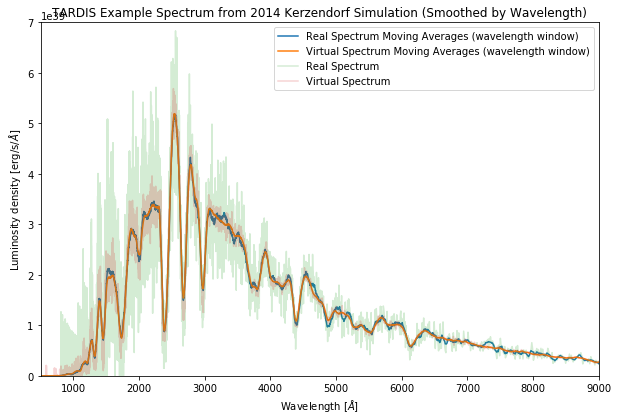

In [334]:
plt.figure(figsize=(10, 6.5))
plt.plot(x_mov, y_mov, label="Real Spectrum Moving Averages (wavelength window)")
plt.plot(xv_mov, yv_mov, label="Virtual Spectrum Moving Averages (wavelength window)")
plt.plot(x_real, y_real, label="Real Spectrum", alpha=0.2)
plt.plot(x_virt, y_virt, label="Virtual Spectrum", alpha=0.2)
plt.xlim(500, 9000)
plt.ylim(0, 7e39)
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Luminosity density [erg/s/$\AA$]")
plt.title("TARDIS Example Spectrum from 2014 Kerzendorf Simulation (Smoothed by Wavelength)")
plt.legend()
plt.show()

Plot the index moving averages for both the real and virtual spectra on the same graph, along with the original spectra for reference.

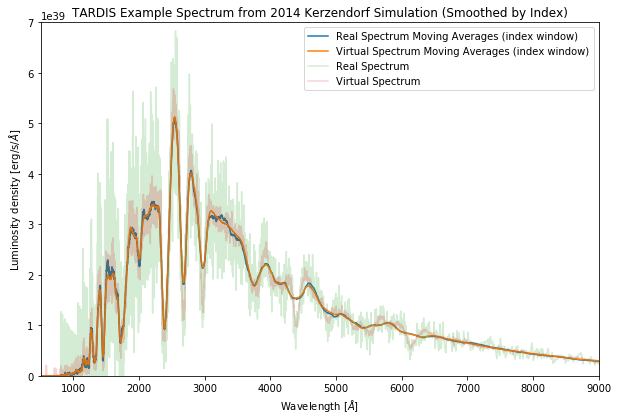

In [335]:
plt.figure(figsize=(10, 6.5))
plt.plot(x_mov_i, y_mov_i, label="Real Spectrum Moving Averages (index window)")
plt.plot(xv_mov_i, yv_mov_i, label="Virtual Spectrum Moving Averages (index window)")
plt.plot(x_real, y_real, label="Real Spectrum", alpha=0.2)
plt.plot(x_virt, y_virt, label="Virtual Spectrum", alpha=0.2)
plt.xlim(500, 9000)
plt.ylim(0, 7e39)
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Luminosity density [erg/s/$\AA$]")
plt.title("TARDIS Example Spectrum from 2014 Kerzendorf Simulation (Smoothed by Index)")
plt.legend()
plt.show()

Take the residuals of the real and virtual spectra with their respective wavelength moving averages and plot them.

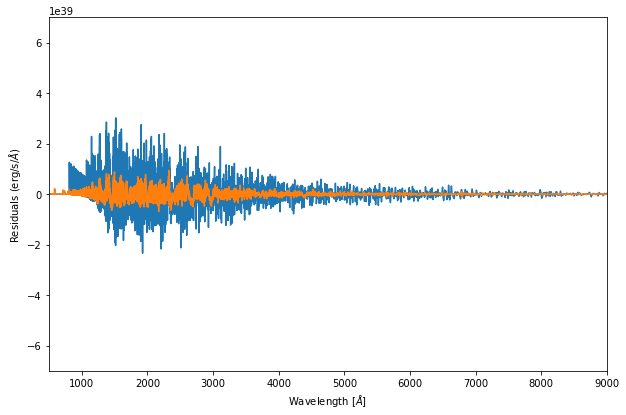

In [336]:
y_residuals = residuals(y_real, y_mov)
yv_residuals = residuals(y_virt, yv_mov)
plt.figure(figsize=(10, 6.5))
plt.plot(x_mov, y_residuals, label="Residuals (Real Spectrum - Moving Average)")
plt.plot(x_mov, yv_residuals, label="Residuals (Virtual Spectrum - Moving Average)")
plt.xlim(500, 9000)
plt.ylim(-7e39, 7e39)
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Residuals (erg/s/$\AA$)")

Find the fractional difference between the residuals and the moving average for the real spectrum and plot it against wavelength.  
This gives us a sense of what the "noise" looks like in the spectra in % difference from the moving average, which can be useful for understanding the SNR and the effectiveness  
of the smoothing algorithm.  
However, the SNR measurements done earlier are more quantitative and should be the primary way to evaluate the SNR, while this plot can be used for a more qualitative assessment.

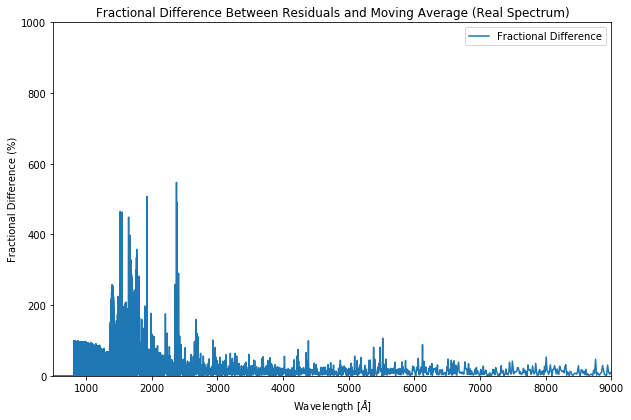

In [337]:
# Explanation of units of y-axis: Units are in %, so at "200," the value represents a 200% (or 2x) difference from the moving average.

fracdif_real = fracdif(y_real, y_mov)

plt.figure(figsize=(10, 6.5))
plt.plot(x_mov, fracdif_real, label="Fractional Difference")
plt.xlim(500, 9000)
plt.ylim(0, 1000)
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Fractional Difference (%)")
plt.title("Fractional Difference Between Residuals and Moving Average (Real Spectrum)")
plt.legend()
plt.show()

# Smooth the Kerz_2014 data using a Savistky-Goley Filter

### In this section, we use a Savitsky-Goley to reduce the noise in the data from the TARDIS Setups folder

Apply the Savitzky-Golay filter to both the real and virtual spectra and plot the results on the same graph.

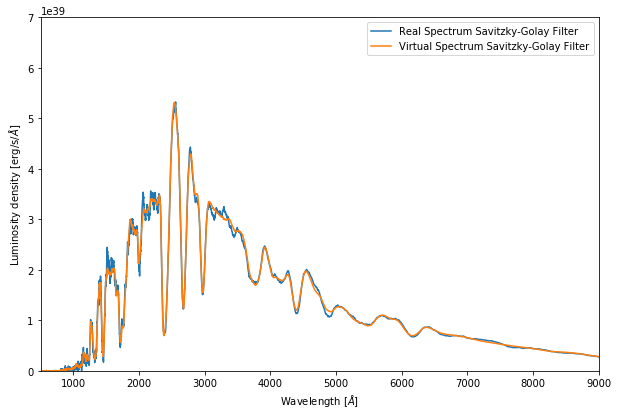

In [338]:
savgol = savgol_filter(y_real, 65, 2)
savgol_virt = savgol_filter(y_virt, 65, 2)

plt.figure(figsize=(10, 6.5))
plt.plot(x_real, savgol, label="Real Spectrum Savitzky-Golay Filter")
plt.plot(x_virt, savgol_virt, label="Virtual Spectrum Savitzky-Golay Filter")
plt.legend()
plt.xlim(500, 9000)
plt.ylim(0, 7e39)
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Luminosity density [erg/s/$\AA$]")

# Run TARDIS to get the 2014 generated example spectrum

### This section runs and plots a TARDIS simulation

Run the TARDIS Simulation

In [339]:
sim = run_tardis("kerz2014_tardis.yml")
spectrum = sim.runner.spectrum
spectrum_virtual = sim.runner.spectrum_virtual

[tardis.plasma.standard_plasmas][INFO   ]  Reading Atomic Data from kurucz_cd23_chianti_H_He.h5 (standard_plasmas.py:77)
tardis.plasma.standard_plasmas - INFO - Reading Atomic Data from kurucz_cd23_chianti_H_He.h5
[tardis.io.atomic    ][INFO   ]  Read Atom Data with UUID=6f7b09e887a311e7a06b246e96350010 and MD5=864f1753714343c41f99cb065710cace. (atomic.py:173)
tardis.io.atomic - INFO - Read Atom Data with UUID=6f7b09e887a311e7a06b246e96350010 and MD5=864f1753714343c41f99cb065710cace.
[tardis.io.atomic    ][INFO   ]  Non provided atomic data: synpp_refs, ion_cx_th_data, ion_cx_sp_data (atomic.py:176)
tardis.io.atomic - INFO - Non provided atomic data: synpp_refs, ion_cx_th_data, ion_cx_sp_data
[tardis.plasma.base  ][DEBUG  ]  Updating modules in the following order: SelectedAtoms->IonizationData->Lines->AtomicMass->Levels->LinesLowerLevelIndex->BetaRadiation->GElectron->LevelBoltzmannFactorLTE->LevelBoltzmannFactorNoNLTE->PartitionFunction->PhiSahaLTE->JBluesDiluteBlackBody->ElectronTem

Separate all the lists of values we need to work with and reverse them for ease of use later on.

In [340]:
spec_l = spectrum.luminosity_density_lambda.value
virt_l = spectrum_virtual.luminosity_density_lambda.value

spec_w = spectrum.wavelength.value
virt_w = spectrum_virtual.wavelength.value


spec_lums = spec_l.tolist()
spec_wavs = spec_w.tolist()
virt_lums = virt_l.tolist()
virt_wavs = virt_w.tolist()

spec_lums.reverse()
spec_wavs.reverse()
virt_lums.reverse()
virt_wavs.reverse()

Plot the TARDIS spectrum we just generated.

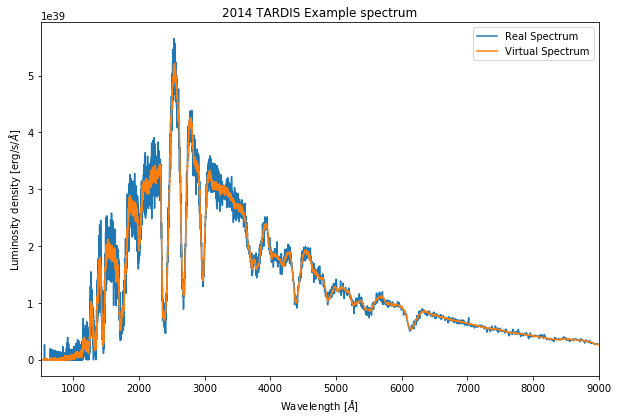

In [341]:
%matplotlib inline
plt.figure(figsize=(10, 6.5))
plt.plot(spec_wavs, spec_lums, label="Real Spectrum")
plt.plot(virt_wavs, virt_lums, label="Virtual Spectrum")

plt.xlim(500, 9000)
plt.title("2014 TARDIS Example spectrum")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Luminosity density [erg/s/$\AA$]")
plt.legend()
plt.show()

# Measure Montecarlo Noise of the Sampled Data using Signal to Noise Ratio

### In this section, we measure the Signal to Noise Ratio and the Standard Deviation of the files in the TARDIS Setups folder in all three defined ranges

Find the SNR and Standard Deviation for the first range in both the real and virtual spectra. Also plot the spectra in that range to visually confirm the lack of spectral features.

Standard Deviation = 2.65969440933e+38
SNR for 2175 to 2275 Angstroms = 12.0707191727
Standard Deviation = 7.00813513235e+37
SNR for 2175 to 2275 Angstroms = 46.0340316792


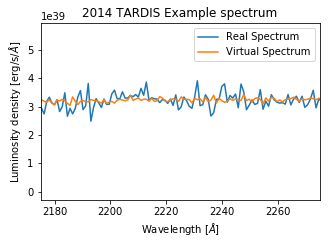

In [342]:
# {start1} to {stop1}
snra = signal_to_noise(spec_lums, start1_index, stop1_index)
print("SNR for {} to {} Angstroms = {}".format(start1, stop1, snra))

snrva = signal_to_noise(virt_lums, start1_index, stop1_index)
print("SNR for {} to {} Angstroms = {}".format(start1, stop1, snrva))



plt.figure(figsize=(5, 3.25))
plt.plot(spec_wavs, spec_lums, label="Real Spectrum")
plt.plot(virt_wavs, virt_lums, label="Virtual Spectrum")

plt.xlim(start1, stop1)
plt.title("2014 TARDIS Example spectrum")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Luminosity density [erg/s/$\AA$]")
plt.legend()

Find the SNR and Standard Deviation for the second range in both the real and virtual spectra. Also plot the spectra in that range to visually confirm the lack of spectral features.

Standard Deviation = 1.76041162743e+38
SNR for 3100 to 3200 Angstroms = 17.6038128725
Standard Deviation = 4.64429479492e+37
SNR for 3100 to 3200 Angstroms = 66.1762581817


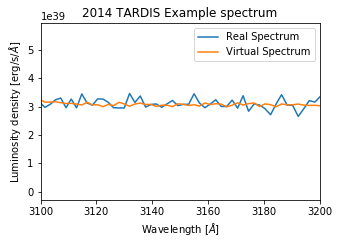

In [343]:
# {start2} to {stop2}
snrb = signal_to_noise(spec_lums, start2_index, stop2_index)
print("SNR for {} to {} Angstroms = {}".format(start2, stop2, snrb))

snrvb = signal_to_noise(virt_lums, start2_index, stop2_index)
print("SNR for {} to {} Angstroms = {}".format(start2, stop2, snrvb))

plt.figure(figsize=(5, 3.25))
plt.plot(spec_wavs, spec_lums, label="Real Spectrum")
plt.plot(virt_wavs, virt_lums, label="Virtual Spectrum")

plt.xlim(start2, stop2)
plt.title("2014 TARDIS Example spectrum")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Luminosity density [erg/s/$\AA$]")
plt.legend()

Find the SNR and Standard Deviation for the third range in both the real and virtual spectra. Also plot the spectra in that range to visually confirm the lack of spectral features.

Standard Deviation = 3.40054168674e+37
SNR for 6800 to 7000 Angstroms = 19.5410138458
Standard Deviation = 1.56671916721e+37
SNR for 6800 to 7000 Angstroms = 42.6259217267


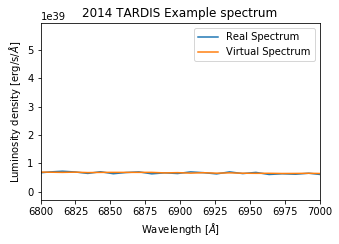

In [344]:
# {start3} to {stop3}
snrc = signal_to_noise(spec_lums, start3_index, stop3_index)
print("SNR for {} to {} Angstroms = {}".format(start3, stop3, snrc))

snrvc = signal_to_noise(virt_lums, start3_index, stop3_index)
print("SNR for {} to {} Angstroms = {}".format(start3, stop3, snrvc))

plt.figure(figsize=(5, 3.25))
plt.plot(spec_wavs, spec_lums, label="Real Spectrum")
plt.plot(virt_wavs, virt_lums, label="Virtual Spectrum")

plt.xlim(start3, stop3)
plt.title("2014 TARDIS Example spectrum")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Luminosity density [erg/s/$\AA$]")
plt.legend()

Plot the signal to noise ratio for the Real and Virtual Spectra in each window in a histogram.

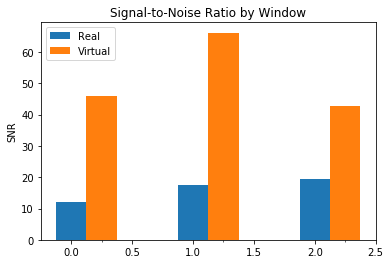

In [345]:
windows = ["{}-{} Angstroms".format(start1,stop1), "{}-{} Angstroms".format(start2,stop2), "{}-{} Angstroms".format(start3,stop3)]
snrs = {"Real": [round(snra, 2), round(snrb, 2), round(snrc, 2)], "Virtual": [round(snrva, 2), round(snrvb, 2), round(snrvc, 2)]}

x = np.arange(len(windows))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots()

for attribute, measurement in snrs.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('SNR')
ax.set_title('Signal-to-Noise Ratio by Window')
ax.set_xticks(x + width, windows)
ax.legend(loc='upper left')

plt.show()

# Smooth The Sampled Data using several methods

### These methods include a windowed moving average using both wavelength and indices, a savitsky-goley filter, and a gaussian filter.

### Windowed Moving Average (Index)

Define the window size and use the moving average function on the data

In [346]:
wsize = 65

spec_wavs_mov, spec_lums_mov = moving_avg_ind(spec_wavs, spec_lums, wsize)
virt_wavs_mov, virt_lums_mov = moving_avg_ind(virt_wavs, virt_lums, wsize)

Plot the smoothed spectrum with the original spectrum behind it for comparison

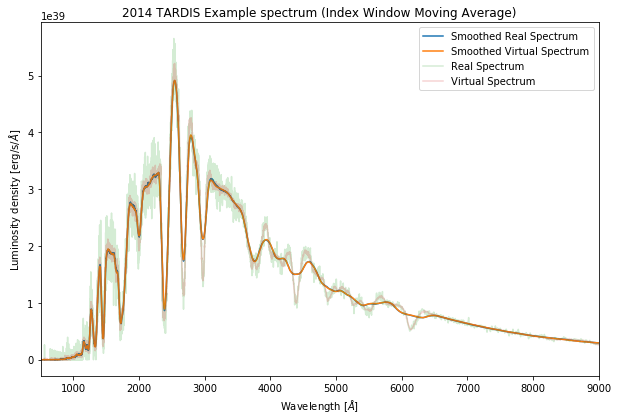

In [347]:
%matplotlib inline
plt.figure(figsize=(10, 6.5))

plt.plot(spec_wavs_mov, spec_lums_mov, label="Smoothed Real Spectrum")
plt.plot(virt_wavs_mov, virt_lums_mov, label="Smoothed Virtual Spectrum")

plt.plot(spec_wavs, spec_lums, label="Real Spectrum", alpha=0.2)
plt.plot(virt_wavs, virt_lums, label="Virtual Spectrum", alpha=0.2)

plt.xlim(500, 9000)
plt.title("2014 TARDIS Example spectrum (Index Window Moving Average)")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Luminosity density [erg/s/$\AA$]")
plt.legend()
plt.show()

### Windowed Moving Average (Wavelength)

Use the wavelength moving average function on the data from the simulation

In [348]:
spec_wavs_mov_w, spec_lums_mov_w = moving_avg_wl(spec_wavs, spec_lums, wsize)
virt_wavs_mov_w, virt_lums_mov_w = moving_avg_wl(virt_wavs, virt_lums, wsize)

Plot the smoothed data with the original spectrum behind it for comparison

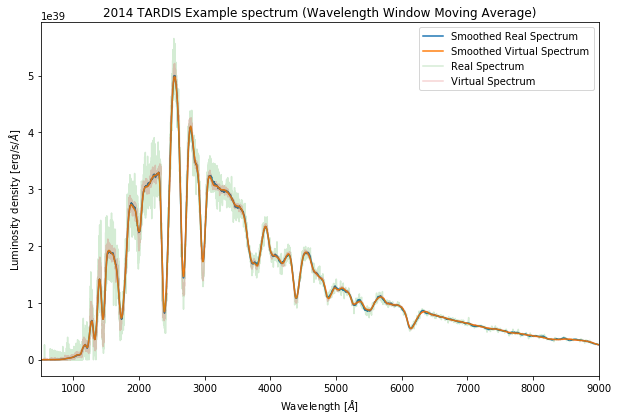

In [349]:
%matplotlib inline
plt.figure(figsize=(10, 6.5))

plt.plot(spec_wavs_mov_w, spec_lums_mov_w, label="Smoothed Real Spectrum")
plt.plot(virt_wavs_mov_w, virt_lums_mov_w, label="Smoothed Virtual Spectrum")

plt.plot(spec_wavs, spec_lums, label="Real Spectrum", alpha=0.2)
plt.plot(virt_wavs, virt_lums, label="Virtual Spectrum", alpha=0.2)

plt.xlim(500, 9000)
plt.title("2014 TARDIS Example spectrum (Wavelength Window Moving Average)")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Luminosity density [erg/s/$\AA$]")
plt.legend()
plt.show()

### Gaussian Filter

Use the Gaussian Filter function on the simulated data

In [350]:
spec_lums_gauss = gauss(spec_lums, sigma=16)
virt_lums_gauss = gauss(virt_lums, sigma=16)

Plot the smoothed data with the original spectrum behind it for comparison

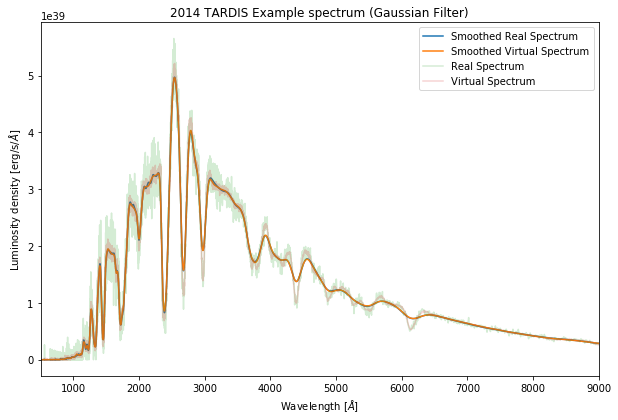

In [351]:
%matplotlib inline
plt.figure(figsize=(10, 6.5))

plt.plot(spec_wavs, spec_lums_gauss, label="Smoothed Real Spectrum")
plt.plot(virt_wavs, virt_lums_gauss, label="Smoothed Virtual Spectrum")

plt.plot(spec_wavs, spec_lums, label="Real Spectrum", alpha=0.2)
plt.plot(virt_wavs, virt_lums, label="Virtual Spectrum", alpha=0.2)

plt.xlim(500, 9000)
plt.title("2014 TARDIS Example spectrum (Gaussian Filter)")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Luminosity density [erg/s/$\AA$]")
plt.legend()
plt.show()

### Savistky-Golay Filter

Use the Savitsky-Goley Filter function on the data

In [352]:
savgol = savgol_filter(spec_lums, 65, 2)
savgol_virt = savgol_filter(virt_lums, 65, 2)

Plot the smoothed data with the original spectrum behind it for comparison

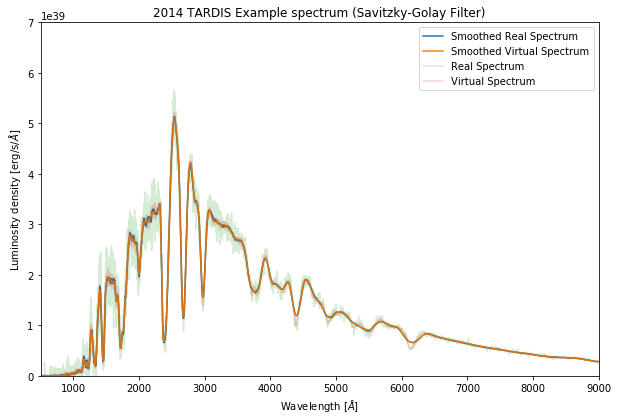

In [353]:
plt.figure(figsize=(10, 6.5))

plt.plot(x_real, savgol, label="Smoothed Real Spectrum")
plt.plot(x_virt, savgol_virt, label="Smoothed Virtual Spectrum")

plt.plot(spec_wavs, spec_lums, label="Real Spectrum", alpha=0.2)
plt.plot(virt_wavs, virt_lums, label="Virtual Spectrum", alpha=0.2)

plt.legend()
plt.title("2014 TARDIS Example spectrum (Savitzky-Golay Filter)")
plt.xlim(500, 9000)
plt.ylim(0, 7e39)
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Luminosity density [erg/s/$\AA$]")

# Graph the Residual Plot (Sampled from 2014 TARDIS minus old data)

### This section subtracts the 2014 data from the 2014 TARDIS spectrum and graphs the plot of those residuals.

Use the residual function on the simulated data and the data obtained from the TARDIS Setups folder

In [354]:
residual_real = residuals(spec_lums, y_real)
residual_virt = residuals(virt_lums, y_virt)

Plot the residuals

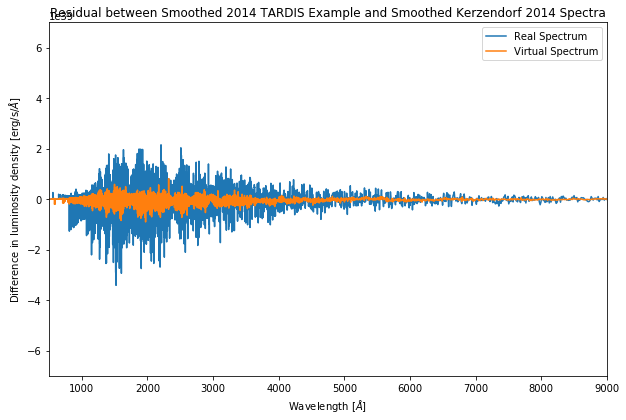

In [355]:
plt.figure(figsize=(10, 6.5))
plt.plot(spec_wavs_mov, residual_real, label="Real Spectrum")
plt.plot(virt_wavs_mov, residual_virt, label="Virtual Spectrum")
plt.xlim(500, 9000)
plt.ylim(-7e39, 7e39)
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Difference in luminosity density [erg/s/$\AA$]")
plt.title("Residual between Smoothed 2014 TARDIS Example and Smoothed Kerzendorf 2014 Spectra")
plt.legend()
plt.show()

Find the standard deviation of the residuals for the real and virtual spectra in each window

In [356]:
print("Std Dev of the Residual between {} and {} Angstroms".format(start1, stop1))

dfr = pd.DataFrame({"Luminosity Residual StdDev (Real):": residual_real[start1_index:stop1_index]})
print(dfr.std())
dfv = pd.DataFrame({"Luminosity Residual StdDev (Virtual):": residual_virt[start1_index:stop1_index]})
print(dfv.std())

Std Dev of the Residual between 2175 and 2275 Angstroms
Luminosity Residual StdDev (Real):    9.023054e+38
dtype: float64
Luminosity Residual StdDev (Virtual):    2.162008e+38
dtype: float64


In [357]:
print("Std Dev of the Residual between {} and {} Angstroms".format(start2, stop2))

dfr = pd.DataFrame({"Luminosity Residual StdDev (Real):": residual_real[start2_index:stop2_index]})
print(dfr.std())
dfv = pd.DataFrame({"Luminosity Residual StdDev (Virtual):": residual_virt[start2_index:stop2_index]})
print(dfv.std())

Std Dev of the Residual between 3100 and 3200 Angstroms
Luminosity Residual StdDev (Real):    5.552339e+38
dtype: float64
Luminosity Residual StdDev (Virtual):    1.113920e+38
dtype: float64


In [358]:
print("Std Dev of the Residual between {} and {} Angstroms".format(start3, stop3))

dfr = pd.DataFrame({"Luminosity Residual (Real):": residual_real[start3_index:stop3_index]})
print(dfr.std())
dfv = pd.DataFrame({"Luminosity Residual (Virtual):": residual_virt[start3_index:stop3_index]})
print(dfv.std())

Std Dev of the Residual between 6800 and 7000 Angstroms
Luminosity Residual (Real):    9.695884e+37
dtype: float64
Luminosity Residual (Virtual):    3.066495e+37
dtype: float64


Find the Fractional Difference between the spectra  
This measurement shows us how different the two spectra are in % (i.e., if the Fractional Difference is 40%, then the residual between the two spectra is 40% of the value of the simulated data at each point)

In [359]:
fracdif_real = fracdif(spec_lums, y_real)

fracdif_virt = fracdif(virt_lums, y_virt)

Plot the fractional difference

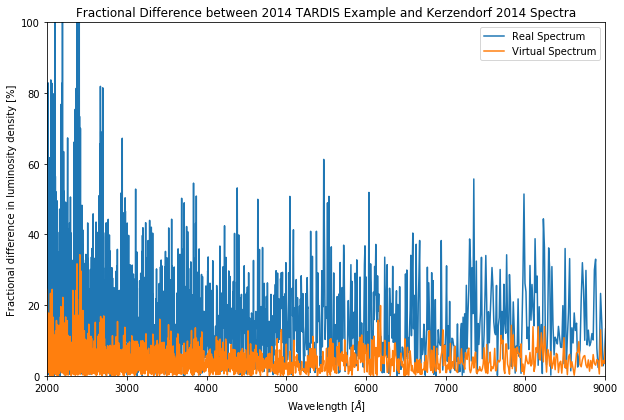

In [360]:
plt.figure(figsize=(10, 6.5))
plt.plot(x_mov, fracdif_real, label="Real Spectrum")
plt.plot(xv_mov, fracdif_virt, label="Virtual Spectrum")
plt.xlim(2000, 9000)
plt.ylim(0,100)
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Fractional difference in luminosity density [%]")
plt.title("Fractional Difference between 2014 TARDIS Example and Kerzendorf 2014 Spectra")
plt.legend()
plt.show()

# Standardized Residual Plot

### This section calculates and plots the standardized residuals, which shows us how many standard deviations each residual point is from the mean

Apply the moving standard deviation function to find a stddev for each point, then use that in the standard residual formula to find the standard residuals for the real and virtual spectra

In [361]:
moving_standard_devs = moving_std_wavelength(x_real, residual_real, 300)

std_residual_real = []
for i in range(len(residual_real)):
    if moving_standard_devs[i] != 0 and np.isfinite(moving_standard_devs[i]):
        std_residual_real.append(residual_real[i] / moving_standard_devs[i])
    else:
        std_residual_real.append(np.nan)

std_residual_real = np.asarray(std_residual_real)


moving_standard_devs = moving_std_wavelength(x_real, residual_virt, 300)

std_residual_virt = []
for i in range(len(residual_virt)):
    if moving_standard_devs[i] != 0 and np.isfinite(moving_standard_devs[i]):
        std_residual_virt.append(residual_virt[i] / moving_standard_devs[i])
    else:
        std_residual_virt.append(np.nan)

std_residual_virt = np.asarray(std_residual_virt)

Plot the standardized residual plot so we can see how far each point is in standard devs from the expected value of the spectrum

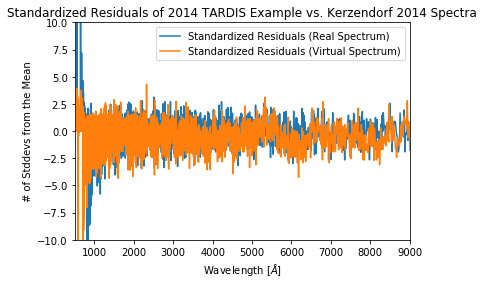

In [362]:
plt.plot(x_real, std_residual_real, label="Standardized Residuals (Real Spectrum)")
plt.plot(x_virt, std_residual_virt, label="Standardized Residuals (Virtual Spectrum)")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel("# of Stddevs from the Mean")
plt.title("Standardized Residuals of 2014 TARDIS Example vs. Kerzendorf 2014 Spectra")
plt.xlim(500, 9000)
plt.ylim(-10, 10)
plt.legend()

In [363]:
data = std_residual_real[start2_index:stop2_index]
print(data)

[  1.28047321e-01   6.50969931e-01  -9.99471796e-01  -4.57312164e-02
  -1.52899292e+00  -3.26059764e+00   3.07863079e-01   1.72101071e+00
   1.78336553e+00  -1.85078203e-01   6.65134116e-01   1.20595196e+00
  -1.32034755e-01   3.63395921e-01   1.89598554e+00   5.36296386e-03
   1.57123219e+00  -8.86786507e-02   1.62201842e-01   2.77709508e-01
  -7.41860419e-02  -3.38524845e-01   5.46367507e-02  -9.10206610e-01
   3.39255241e-01  -7.14523600e-01  -3.40625658e-01  -6.38940193e-01
   9.44935328e-01   4.17997341e-01   5.61401635e-01  -1.45175975e+00
   8.84880525e-01  -6.50526042e-01  -5.55751049e-01   1.32670790e+00
   6.81455274e-02   1.22606154e-01  -1.44677460e+00   9.62964152e-01
   1.61327179e-01   2.32983527e-01  -4.09662902e-01  -5.01724043e-01
   8.69975701e-01  -9.81989600e-01  -4.96814424e-01  -1.64696080e+00
  -4.66264483e-04   2.24124653e+00  -3.29249665e-01]


Since the real packet data is exactly the same between the kerzendorf sim data and the 2014 tardis simulation, we can't compute standardized residuals.  
This is because the standard deviation is 0, and we have to divide by that to get the standard residuals.  
This means we are unable to create a histogram, but we know that the data is exactly the same so we don't need one.

In [364]:
#print(start2_index, stop2_index)
#print(start2, stop2)
#plt.hist(std_residual_real[start2_index:stop2_index], bins=15, alpha=0.5, label="Virtual Spectrum")
#plt.xlabel("Standardized Residuals")
#plt.ylabel("Frequency")
#plt.title("Distribution of Standardized Residuals for Real Spectrum")
#plt.xlim(-5,5)
#plt.legend()
#plt.show()

# Writing 2014 Real TARDIS Spectrum to .csv File

Make sure variables are still correct by plotting the spectrum

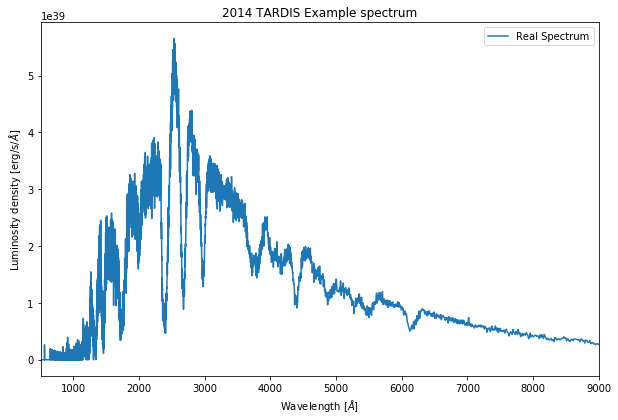

In [365]:
# Check to make sure variables are still correct
%matplotlib inline
plt.figure(figsize=(10, 6.5))
plt.plot(spec_wavs, spec_lums, label="Real Spectrum")

plt.xlim(500, 9000)
plt.title("2014 TARDIS Example spectrum")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Luminosity density [erg/s/$\AA$]")
plt.legend()
plt.show()

Write the data to the csv file

In [366]:
import csv

with open('tardis_comparison_data_2014.csv', mode='w') as file:
    writer = csv.writer(file)
    writer.writerow(['Wavelength (Angstroms)', 'Real Spectrum Luminosity Density (erg/s/Angstrom)'])
    for w, r in zip(spec_wavs, spec_lums):
        writer.writerow([w, r])